## ECON4060H 2021 Winter
## Quantitative Methods in Economics
### Week 3 Companion for Approximation, Interpolation, and Integration
### Shutao Cao

## 1 Approximation

<a id='index-1'></a>


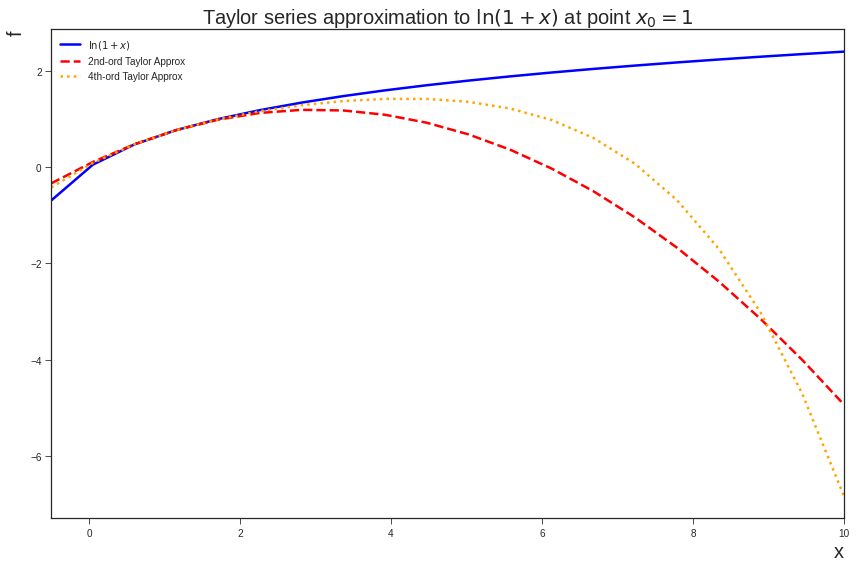

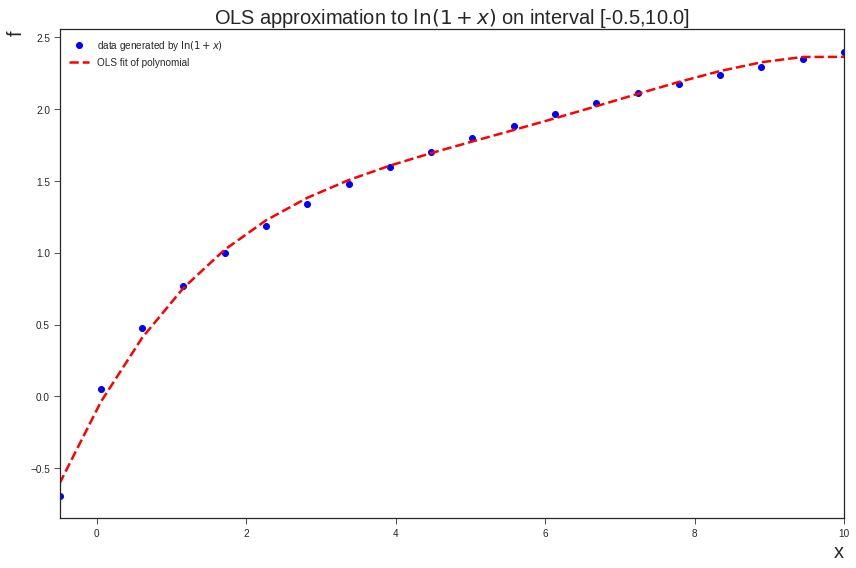

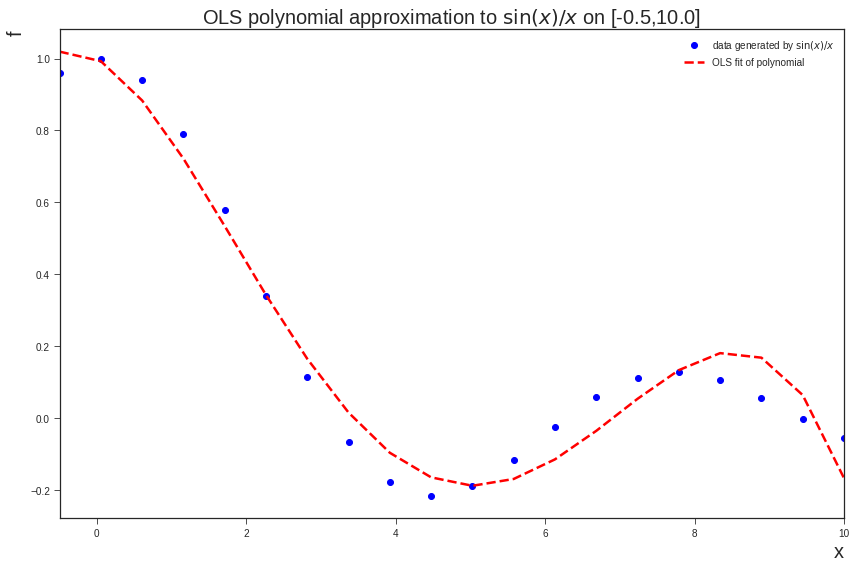

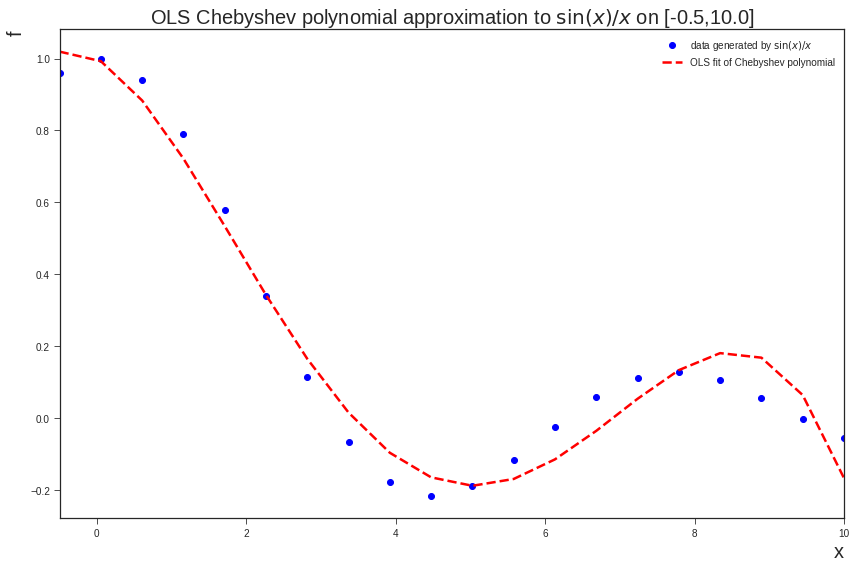

In [1]:
import math
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-ticks')

#---tayler series approximation of ln(1+x) of order 2 order 4
def taylorapp (x,a,n):
    f0 = np.log(1.0+a)
    f1 = 1.0/(1.0+a)
    f2 = 1.0/(1.0+a)**(2)
    f3 = f1*f2
    f4 = f1*f3
    if n==2:
        return f0+f1*(x-a) - f2*(x-a)**2/math.factorial(2)
    elif n==3:
        return f0+f1*(x-a) - f2*(x-a)**2/math.factorial(2) + f3*(x-a)**3/math.factorial(3)
    else:
        return f0+f1*(x-a) - f2*(x-a)**2/math.factorial(2) + f3*(x-a)**3/math.factorial(3) - f4*(x-a)**4/math.factorial(4)

x = np.linspace(-0.5, 10.0, num=20, endpoint=True)
y = np.log(1.0+x)
# ytaylor2d0 = 
ftaylor20 = taylorapp (x,1,2)
ftaylor40 = taylorapp (x,1,4)

lwidth=2.5
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 8), sharey='all')
ax.plot(x, y, color="blue", linewidth=lwidth, linestyle="-",label="$\ln (1+x)$")
ax.plot(x, ftaylor20, color="red", linewidth=lwidth, linestyle="--",label="2nd-ord Taylor Approx")
ax.plot(x, ftaylor40, color="orange", linewidth=lwidth, linestyle=":",label="4th-ord Taylor Approx")
plt.autoscale(enable=True, axis='x', tight=True)
ax.set_title("Taylor series approximation to $\ln (1+x)$ at point $x_0=1$", fontsize=20)
plt.xlabel("x", loc='right',fontsize=20)
ax.set_ylabel("f", loc='top',fontsize=20)
ax.legend(loc='best')
fig.tight_layout()
plt.show()


#---OLS as a global approximation of ln(1+x) with 3rd-order polynomials
from numpy.polynomial import polynomial as ply
a, stats = ply.polyfit(x,y,deg=4,full=True)
yfit = a[0] + a[1]*x + a[2]*x*x + a[3]*x*x*x+a[4]*x*x*x*x
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 8), sharey='all')
ax.plot(x, y, "o", color="blue",label="data generated by $\ln (1+x)$")
ax.plot(x, yfit, color="red", linewidth=lwidth, linestyle="--",label="OLS fit of polynomial")
plt.autoscale(enable=True, axis='x', tight=True)
ax.set_title("OLS approximation to $\ln (1+x)$ on interval [-0.5,10.0]", fontsize=20)
plt.xlabel("x", loc='right',fontsize=20)
ax.set_ylabel("f", loc='top',fontsize=20)
ax.legend(loc='best')
fig.tight_layout()
plt.show()


#---OLS as a global approximation of sin(x) / x with 3rd-order polynomials
y2 = np.sin(x) / x
from numpy.polynomial import polynomial as ply
a2, stats = ply.polyfit(x,y2,deg=4,full=True)

y2fit = a2[0] + a2[1]*x + a2[2]*x*x + a2[3]*x*x*x + a2[4]*x**4 
#+ a2[5]*x**5+ a2[6]*x**6
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 8), sharey='all')
ax.plot(x, y2, "o", color="blue",label="data generated by $\sin (x) / x$")
ax.plot(x, y2fit, color="red", linewidth=lwidth, linestyle="--",label="OLS fit of polynomial")
plt.autoscale(enable=True, axis='x', tight=True)
ax.set_title("OLS polynomial approximation to $\sin (x) / x$ on [-0.5,10.0]", fontsize=20)
plt.xlabel("x", loc='right',fontsize=20)
ax.set_ylabel("f", loc='top',fontsize=20)
ax.legend(loc='best')
fig.tight_layout()
plt.show()


#---OLS fit of Chebyshev polynomial approximation of function sin (x) / x
from numpy.polynomial import chebyshev as C
chebycoef,stats = C.chebfit(x, y2, deg=4,full=True)
y2chebyNew = C.chebval(x, chebycoef, tensor=True)
# Below, Chebyshev is a class, it contains many functions
y2cheby,stats = C.Chebyshev.fit(x, y2, deg=4,  domain=[-0.5,10.0],full=True)
# y2cheby(x) == y2chebyNew

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 8), sharey='all')
ax.plot(x, y2, "o", color="blue",label="data generated by $\sin (x) / x$")
ax.plot(x, y2cheby(x), color="red", linewidth=lwidth, linestyle="--",label="OLS fit of Chebyshev polynomial")
#ax.plot(x, y2chebyNew, color="green", linewidth=lwidth, linestyle=":",label="OLS fit of Chebyshev polynomial")
plt.autoscale(enable=True, axis='x', tight=True)
ax.set_title("OLS Chebyshev polynomial approximation to $\sin (x) / x$ on [-0.5,10.0]", fontsize=20)
plt.xlabel("x", loc='right',fontsize=20)
ax.set_ylabel("f", loc='top',fontsize=20)
ax.legend(loc='best')
fig.tight_layout()
plt.show()


## 2. Interpolation

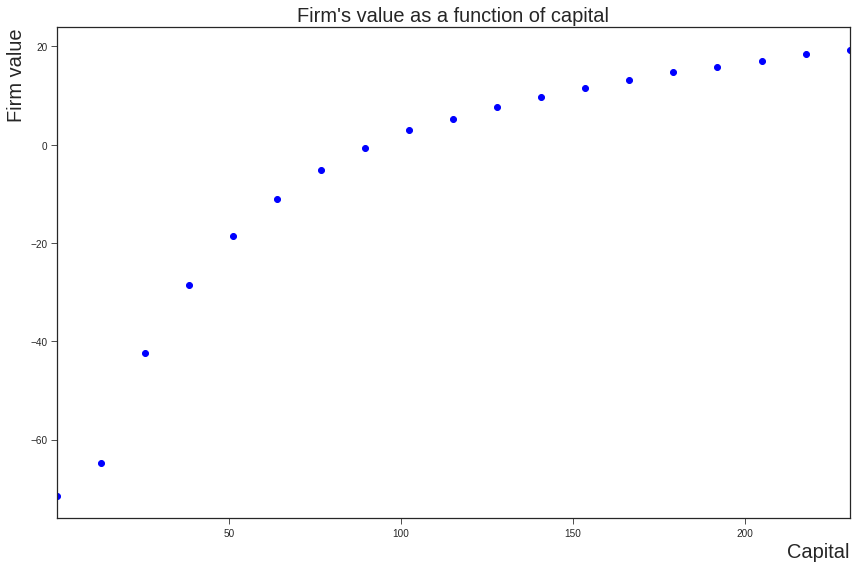

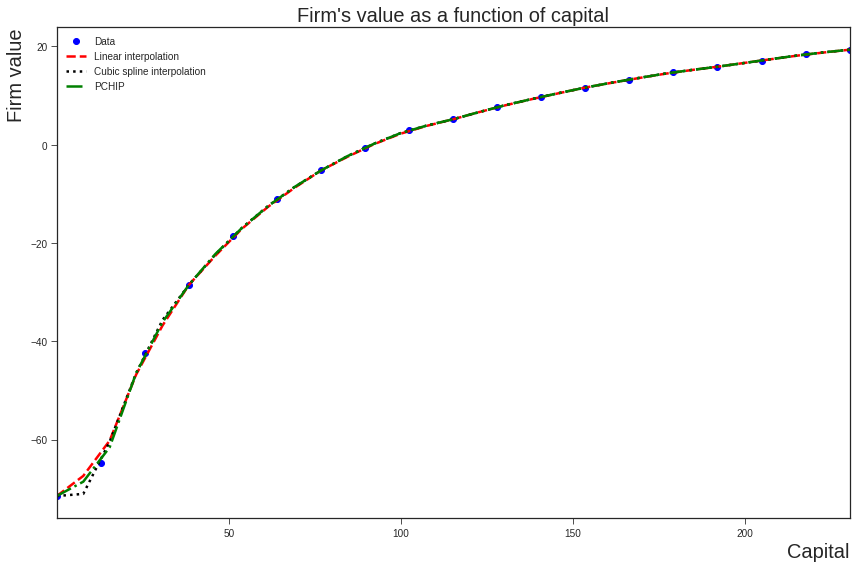

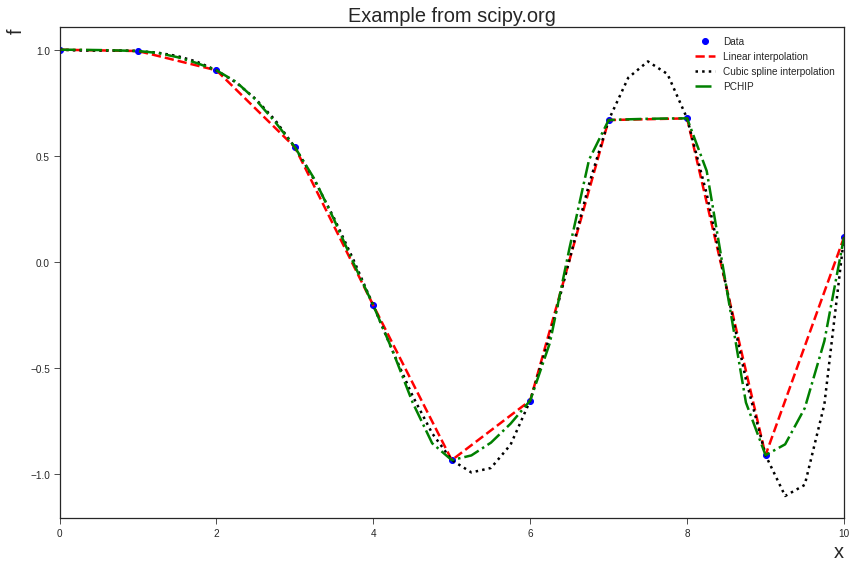

In [2]:
#---------interpolation----------------
# use firm's value function as example, see README.md for data
fname = 'k.csv'
#capital = pd.read_csv(fname, header=0, index_col=None, parse_dates=True)
capital = np.genfromtxt(fname, skip_header=1)
fname = 'v.csv'
#fvalue = pd.read_csv(fname, header=0, index_col=None, parse_dates=True)
fvalue = np.genfromtxt(fname, skip_header=1, delimiter=",")

k = capital[0:19]
v = fvalue[0:19,7]

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 8), sharey='all')
ax.plot(k,v, "o", color="blue",label="Value function")
plt.autoscale(enable=True, axis='x', tight=True)
ax.set_title("Firm's value as a function of capital", fontsize=20)
plt.xlabel("Capital", loc='right',fontsize=20)
ax.set_ylabel("Firm value", loc='top',fontsize=20)
#ax.legend(loc='best')
fig.tight_layout()
plt.show()


#---piecewise linear interpolation and cubic spline interpolation
from scipy import interpolate as itp
vLinear = itp.interp1d(k, v, kind='linear')
vCubic = itp.interp1d(k, v, kind='cubic')
vpchip = itp.PchipInterpolator(k, v, axis=0)

knew = np.linspace(k[0], k[-1], num=31, endpoint=True)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 8), sharey='all')
ax.plot(k,v, "o", color="blue",label="Data")
ax.plot(knew, vLinear(knew), color="red", linewidth=lwidth, linestyle="--",label="Linear interpolation")
ax.plot(knew, vCubic(knew), color="black", linewidth=lwidth, linestyle=":",label="Cubic spline interpolation")
ax.plot(knew, vpchip(knew), color="green", linewidth=lwidth, linestyle="-.",label="PCHIP")
plt.autoscale(enable=True, axis='x', tight=True)
ax.set_title("Firm's value as a function of capital", fontsize=20)
plt.xlabel("Capital", loc='right',fontsize=20)
ax.set_ylabel("Firm value", loc='top',fontsize=20)
ax.legend(loc='best')
fig.tight_layout()
plt.show()


#----interpolation example from scipy.org
x = np.linspace(0, 10, num=11, endpoint=True)
y = np.cos(-x**2/9.0)
f = itp.interp1d(x, y)
f2 = itp.interp1d(x, y, kind='cubic')

fpchip = itp.PchipInterpolator(x, y, axis=0)

xnew = np.linspace(0, 10, num=41, endpoint=True)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 8), sharey='all')
ax.plot(x,y, "o", color="blue",label="Data")
ax.plot(xnew, f(xnew), color="red", linewidth=lwidth, linestyle="--",label="Linear interpolation")
ax.plot(xnew, f2(xnew), color="black", linewidth=lwidth, linestyle=":",label="Cubic spline interpolation")
ax.plot(xnew, fpchip(xnew), color="green", linewidth=lwidth, linestyle="-.",label="PCHIP")
plt.autoscale(enable=True, axis='x', tight=True)
ax.set_title("Example from scipy.org", fontsize=20)
plt.xlabel("x", loc='right',fontsize=20)
ax.set_ylabel("f", loc='top',fontsize=20)
ax.legend(loc='best')
fig.tight_layout()
plt.show()



## 3. Integration

In [3]:
#-------integrating function sin x / x
import numpy as np
from scipy import integrate
f = lambda x: np.sin(x) /x 

f_int, error = integrate.quadrature(f, -0.5, 10.0)
f_int

2.1514550122719904